# Capital Bikeshare Hourly Demand: Preliminary Data Analysis

I'm doing some preliminary analysis for `bike_sharing_hourly.csv`.

In [3]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "bike_sharing_hourly.csv"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "bikeshare_prelim_eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


## 1. Load Data and Add Readable Labels

The raw file has coded variables such as `season`, `weekday`, and `weathersit`. We keep the original columns, but add labels for interpretation (e.g. 1,2,3,4 -> winter, spring... for season). Also parse the date to construct hourly timestamps.


In [4]:
df = pd.read_csv(DATA_PATH)

# Parse date and construct the hourly timestamp.
df["date"] = pd.to_datetime(df["dteday"])
df["timestamp"] = df["date"] + pd.to_timedelta(df["hr"], unit="h")

# Binary target used for classification later.
df["high_demand_flag"] = (df["high_demand"].str.lower() == "high").astype(int)

season_map = {1: "Winter", 2: "Spring", 3: "Summer", 4: "Fall"}
weather_map = {
    1: "Clear/Mist",
    2: "Cloudy/Mist",
    3: "Light Rain/Snow",
    4: "Heavy Rain/Snow",
}
weekday_map = {0: "Sun", 1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"}

# readable labels.
df["season_label"] = df["season"].map(season_map)
df["weather_label"] = df["weathersit"].map(weather_map)
df["weekday_label"] = df["weekday"].map(weekday_map)
df["day_type"] = np.where(df["workingday"].eq(1), "Working day", "Non-working day")
df["year_label"] = np.where(df["yr"].eq(1), "2012", "2011")

print(df.shape)
df.head()


(17379, 26)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,cnt,high_demand,date,timestamp,high_demand_flag,season_label,weather_label,weekday_label,day_type,year_label
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,16,Low,2011-01-01,2011-01-01 00:00:00,0,Winter,Clear/Mist,Sat,Non-working day,2011
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,40,Low,2011-01-01,2011-01-01 01:00:00,0,Winter,Clear/Mist,Sat,Non-working day,2011
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,32,Low,2011-01-01,2011-01-01 02:00:00,0,Winter,Clear/Mist,Sat,Non-working day,2011
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,13,Low,2011-01-01,2011-01-01 03:00:00,0,Winter,Clear/Mist,Sat,Non-working day,2011
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,1,Low,2011-01-01,2011-01-01 04:00:00,0,Winter,Clear/Mist,Sat,Non-working day,2011


## 2. Some cleaning + checks

Key checks:

- Missing values and duplicate rows/timestamps.
- Whether the hourly calendar has gaps.
- Whether variables are coded in expected ranges.
- Whether derived variables cause leakage.
- Whether apparent outliers are data errors or meaningful observations.


In [5]:
missing_by_column = df.isna().sum().sort_values(ascending=False)
duplicate_timestamps = df["timestamp"].duplicated().sum()

expected_hours = pd.date_range(df["timestamp"].min(), df["timestamp"].max(), freq="h")
missing_hours = expected_hours.difference(pd.DatetimeIndex(df["timestamp"]))
missing_hour_days = pd.Series(missing_hours.date).value_counts().head(12)

integrity_summary = pd.DataFrame({
    "check": [
        "rows",
        "raw columns",
        "missing cells",
        "duplicate timestamps",
        "missing hourly timestamps",
        "date start",
        "date end",
    ],
    "value": [
        f"{len(df):,}",
        "18",
        f"{int(missing_by_column.sum()):,}",
        f"{duplicate_timestamps:,}",
        f"{len(missing_hours):,}",
        str(df["timestamp"].min()),
        str(df["timestamp"].max()),
    ]
})

integrity_summary


,check,value
0,rows,"17,379"
1,raw columns,18
2,missing cells,0
3,duplicate timestamps,0
4,missing hourly timestamps,165
5,date start,2011-01-01 00:00:00
6,date end,2012-12-31 23:00:00


In [6]:
print("Missing values by column:")
display(missing_by_column.to_frame("missing_count"))

print("Days with the most missing hourly timestamps:")
display(missing_hour_days.rename("missing_hours").to_frame())


Missing values by column:


,missing_count
instant,0
dteday,0
day_type,0
weekday_label,0
weather_label,0
season_label,0
high_demand_flag,0
timestamp,0
date,0
high_demand,0


Days with the most missing hourly timestamps:


,missing_hours
2012-10-29,23
2011-01-27,16
2012-10-30,13
2011-01-18,12
2011-01-26,8
2011-08-28,7
2011-02-22,6
2011-08-27,6
2011-03-10,2
2011-02-11,2


In [8]:
range_checks = pd.DataFrame({
    "variable": ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit", "temp", "atemp", "hum", "windspeed"],
    "observed_min": [df[c].min() for c in ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit", "temp", "atemp", "hum", "windspeed"]],
    "observed_max": [df[c].max() for c in ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit", "temp", "atemp", "hum", "windspeed"]],
    "n_unique": [df[c].nunique() for c in ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit", "temp", "atemp", "hum", "windspeed"]],
})
range_checks


,variable,observed_min,observed_max,n_unique
0,season,1.00,4.0000,4
1,yr,0.00,1.0000,2
2,mnth,1.00,12.0000,12
3,hr,0.00,23.0000,24
4,holiday,0.00,1.0000,2
5,weekday,0.00,6.0000,7
6,workingday,0.00,1.0000,2
7,weathersit,1.00,4.0000,4
8,temp,0.02,1.0000,50
9,atemp,0.00,1.0000,65


The raw data is already pretty clean. Notably:

1. **No missing-cell imputation is needed.** The CSV has no blank values.
2. **Calendar gaps exist.** There are missing hourly timestamps, especially around storms or unusual days. 
3. **Do not use `casual` and `registered` when predicting `cnt` or `high_demand`.** Since `cnt = casual + registered`
4. **Do not treat every coded variable as continuous.** `hr`, `weekday`, `mnth`, `season`, and `weathersit` are categorical or cyclical variables.
5. **Standardize before PCA, clustering, ridge/lasso, or distance-based methods.** The lecture notes emphasize scale because PCA/clustering depend strongly on variance and distance.
6. **`temp` and `atemp` are redundant.** They are nearly perfectly correlated, so use one of them, combine them, or use regularization.
7. **Peak counts are not automatic data errors.** High values mostly correspond to commute/event demand and should be interpreted rather than deleted.


In [9]:
leakage_check = (df["casual"] + df["registered"] == df["cnt"]).all()

temp_atemp_corr = df[["temp", "atemp"]].corr().iloc[0, 1]
cnt_registered_corr = df[["cnt", "registered"]].corr().iloc[0, 1]
cnt_casual_corr = df[["cnt", "casual"]].corr().iloc[0, 1]

q1, q3 = df["cnt"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_iqr_threshold = q3 + 1.5 * iqr
high_count_outliers = (df["cnt"] > upper_iqr_threshold).sum()

cleaning_notes = pd.DataFrame({
    "issue": [
        "cnt equals casual + registered",
        "corr(temp, atemp)",
        "corr(cnt, registered)",
        "corr(cnt, casual)",
        "median cnt / high-demand threshold",
        "IQR high-count threshold",
        "rows above IQR high-count threshold",
        "zero humidity rows",
        "zero windspeed rows",
    ],
    "finding": [
        leakage_check,
        round(temp_atemp_corr, 3),
        round(cnt_registered_corr, 3),
        round(cnt_casual_corr, 3),
        df["cnt"].median(),
        round(upper_iqr_threshold, 1),
        int(high_count_outliers),
        int((df["hum"] == 0).sum()),
        int((df["windspeed"] == 0).sum()),
    ]
})

cleaning_notes


,issue,finding
0,cnt equals casual + registered,True
1,"corr(temp, atemp)",0.988
2,"corr(cnt, registered)",0.972
3,"corr(cnt, casual)",0.695
4,median cnt / high-demand threshold,142.0
5,IQR high-count threshold,642.5
6,rows above IQR high-count threshold,505
7,zero humidity rows,22
8,zero windspeed rows,2180


## 4. Basic Target and Numeric Summaries


In [10]:
print("Target balance:")
display(df["high_demand"].value_counts().to_frame("count"))

numeric_summary = df[["temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).round(3)

numeric_summary


Target balance:


,count
high_demand,
Low,8708
High,8671


,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000
mean,0.497,0.476,0.627,0.190,35.676,153.787,189.463
std,0.193,0.172,0.193,0.122,49.305,151.357,181.388
min,0.020,0.000,0.000,0.000,0.000,0.000,1.000
1%,0.120,0.121,0.230,0.000,0.000,1.000,2.000
5%,0.200,0.212,0.310,0.000,0.000,4.000,5.000
25%,0.340,0.333,0.480,0.104,4.000,34.000,40.000
50%,0.500,0.485,0.630,0.194,17.000,115.000,142.000
75%,0.660,0.621,0.780,0.254,48.000,220.000,281.000
95%,0.800,0.742,0.930,0.418,138.100,465.000,563.100


## 5. Demand by Hour and Working-Day Status

In [11]:
hour_daytype = (
    df.groupby(["hr", "day_type"])
    .agg(
        mean_cnt=("cnt", "mean"),
        median_cnt=("cnt", "median"),
        high_rate=("high_demand_flag", "mean"),
        n=("cnt", "size"),
    )
    .reset_index()
)

top_hour_daytype = hour_daytype.sort_values("mean_cnt", ascending=False).head(12)
top_hour_daytype


,hr,day_type,mean_cnt,median_cnt,high_rate,n
35,17,Working day,525.290581,539.0,0.961924,499
37,18,Working day,492.226908,504.5,0.951807,498
17,8,Working day,477.006048,463.0,0.963710,496
26,13,Non-working day,372.731602,367.0,0.878788,231
24,12,Non-working day,366.259740,367.0,0.883117,231
28,14,Non-working day,364.645022,361.0,0.891775,231
30,15,Non-working day,358.813853,361.0,0.874459,231
32,16,Non-working day,352.727273,356.0,0.878788,231
39,19,Working day,348.401606,349.5,0.857430,498
34,17,Non-working day,323.549784,322.0,0.818182,231


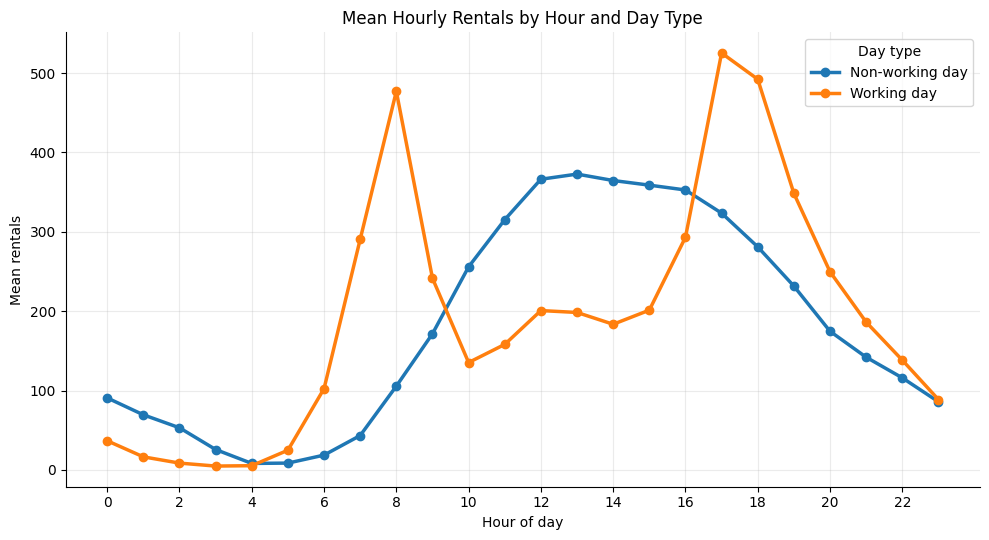

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for label, group in hour_daytype.groupby("day_type"):
    ax.plot(group["hr"], group["mean_cnt"], marker="o", linewidth=2.5, label=label)

ax.set_title("Mean Hourly Rentals by Hour and Day Type")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean rentals")
ax.set_xticks(range(0, 24, 2))
ax.legend(title="Day type")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mean_count_by_hour_workingday.png", dpi=200)
plt.show()


## 6. Weekday-Hour Heatmap
 Weekdays are concentrated around commute hours, while weekends are more spread through the middle of the day.


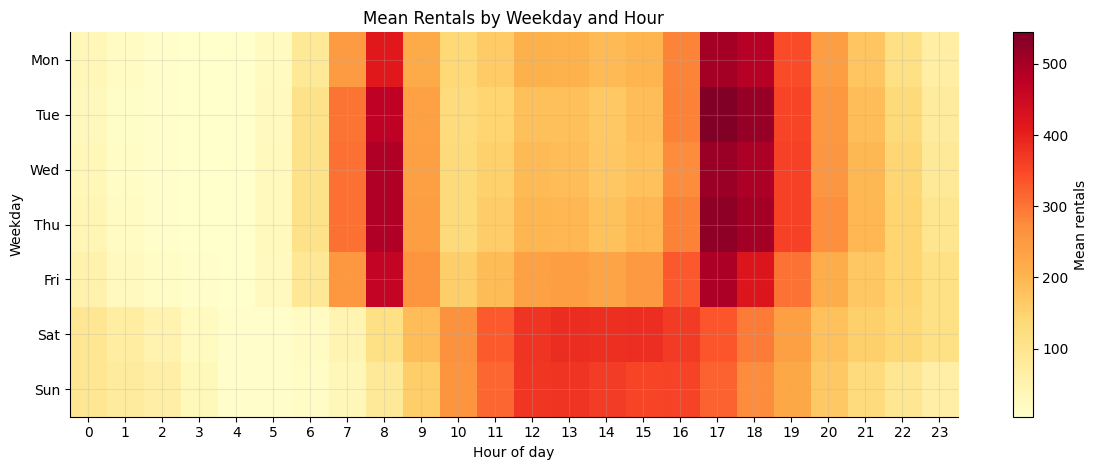

hr,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday_label,,,,,,,,,,,,,,,,,,,,,
Mon,34.0,17.3,10.3,5.1,5.8,21.7,85.9,248.5,412.2,218.4,...,192.7,202.4,284.5,502.4,481.3,344.6,242.1,174.5,115.8,65.4
Tue,27.6,12.5,6.8,4.2,5.1,24.5,106.5,299.7,471.8,236.5,...,168.4,186.9,286.7,544.3,517.6,353.9,253.2,186.2,132.3,76.2
Wed,34.6,15.3,7.8,4.9,5.0,25.8,107.8,304.0,488.3,238.5,...,170.5,181.3,273.0,513.1,494.0,357.5,256.7,194.7,143.7,83.7
Thu,39.3,17.2,9.2,5.1,5.3,25.9,107.4,304.7,488.6,240.9,...,177.6,196.5,286.3,527.3,502.1,358.5,268.9,197.9,147.2,96.8
Fri,52.4,24.7,12.7,6.6,6.1,23.9,90.0,254.3,462.3,259.0,...,229.4,252.5,331.0,492.4,421.0,302.1,213.3,169.9,147.1,115.2
Sat,94.3,67.8,50.5,22.9,7.7,8.3,21.0,46.0,114.5,186.8,...,381.3,382.4,366.1,334.4,292.0,239.9,180.9,156.0,139.7,115.9
Sun,94.0,77.4,61.6,31.1,9.4,8.7,14.5,33.1,83.9,156.5,...,363.6,353.9,355.4,318.8,272.6,225.5,168.0,127.6,94.1,61.9


In [14]:
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekday_hour = (
    df.pivot_table(index="weekday_label", columns="hr", values="cnt", aggfunc="mean")
    .loc[weekday_order]
)

fig, ax = plt.subplots(figsize=(12, 4.8))
im = ax.imshow(weekday_hour.values, aspect="auto", cmap="YlOrRd")

ax.set_title("Mean Rentals by Weekday and Hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Weekday")
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(len(weekday_order)))
ax.set_yticklabels(weekday_order)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Mean rentals")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "weekday_hour_heatmap.png", dpi=200)
plt.show()

weekday_hour.round(1)


## 7. Season, Weather, and Year Effects

Season and weather are plausible predictors, while `yr` captures overall system growth from 2011 to 2012.


In [15]:
def summarize_group(group_col):
    return (
        df.groupby(group_col)
        .agg(mean_cnt=("cnt", "mean"), median_cnt=("cnt", "median"), high_rate=("high_demand_flag", "mean"), n=("cnt", "size"))
        .sort_values("mean_cnt", ascending=False)
        .round(3)
    )

season_summary = summarize_group("season_label")
weather_summary = summarize_group("weather_label")
year_summary = summarize_group("year_label")
weekday_summary = summarize_group("weekday_label")

print("Season summary")
display(season_summary)
print("Weather summary")
display(weather_summary)
print("Year summary")
display(year_summary)


Season summary


,mean_cnt,median_cnt,high_rate,n
season_label,,,,
Summer,236.016,199.0,0.624,4496
Spring,208.344,165.0,0.548,4409
Fall,198.869,155.5,0.533,4232
Winter,111.115,76.0,0.282,4242


Weather summary


,mean_cnt,median_cnt,high_rate,n
weather_label,,,,
Clear/Mist,204.869,159.0,0.536,11413
Cloudy/Mist,175.165,133.0,0.478,4544
Light Rain/Snow,111.579,63.0,0.268,1419
Heavy Rain/Snow,74.333,36.0,0.333,3


Year summary


,mean_cnt,median_cnt,high_rate,n
year_label,,,,
2012,234.666,191.0,0.587,8734
2011,143.794,109.0,0.410,8645


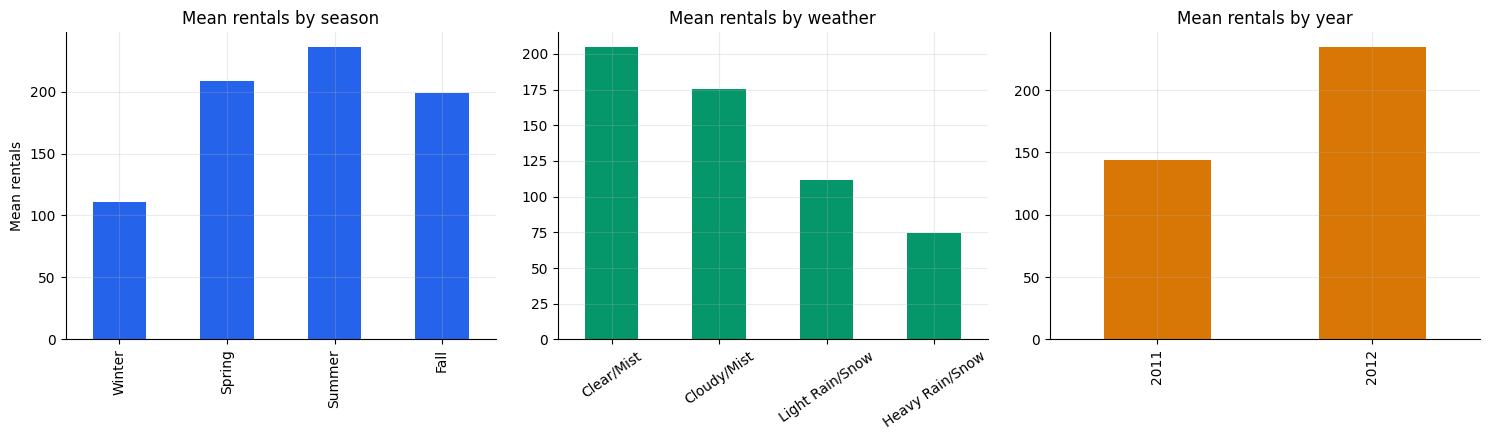

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

season_order = ["Winter", "Spring", "Summer", "Fall"]
weather_order = ["Clear/Mist", "Cloudy/Mist", "Light Rain/Snow", "Heavy Rain/Snow"]
year_order = ["2011", "2012"]

season_summary.loc[season_order, "mean_cnt"].plot(kind="bar", ax=axes[0], color="#2563eb")
axes[0].set_title("Mean rentals by season")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean rentals")

weather_summary.loc[weather_order, "mean_cnt"].plot(kind="bar", ax=axes[1], color="#059669")
axes[1].set_title("Mean rentals by weather")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=35)

year_summary.loc[year_order, "mean_cnt"].plot(kind="bar", ax=axes[2], color="#d97706")
axes[2].set_title("Mean rentals by year")
axes[2].set_xlabel("")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "season_weather_year_summary.png", dpi=200)
plt.show()


## 8. Temperature and Humidity Interaction

Temperature has a positive relationship with demand, but the relationship is not isolated: high humidity appears to suppress demand even when temperature is favorable.


In [17]:
temp_bins = pd.cut(
    df["temp"],
    bins=[-0.001, 0.20, 0.40, 0.60, 0.80, 1.001],
    labels=["<=0.20", "0.20-0.40", "0.40-0.60", "0.60-0.80", ">0.80"],
)
hum_bins = pd.cut(
    df["hum"],
    bins=[-0.001, 0.30, 0.50, 0.70, 0.90, 1.001],
    labels=["<=0.30", "0.30-0.50", "0.50-0.70", "0.70-0.90", ">0.90"],
)

temp_humidity = (
    df.assign(temp_bin=temp_bins, hum_bin=hum_bins)
    .groupby(["temp_bin", "hum_bin"], observed=False)
    .agg(mean_cnt=("cnt", "mean"), high_rate=("high_demand_flag", "mean"), n=("cnt", "size"))
    .reset_index()
)

temp_hum_pivot = temp_humidity.pivot(index="temp_bin", columns="hum_bin", values="mean_cnt")
temp_hum_pivot.round(1)


hum_bin,<=0.30,0.30-0.50,0.50-0.70,0.70-0.90,>0.90
temp_bin,,,,,
<=0.20,91.9,66.0,63.2,64.2,58.8
0.20-0.40,146.1,163.8,118.2,100.9,69.6
0.40-0.60,308.3,283.8,213.3,149.4,88.1
0.60-0.80,414.6,380.3,277.3,162.8,92.9
>0.80,373.5,328.6,282.3,172.2,NaN


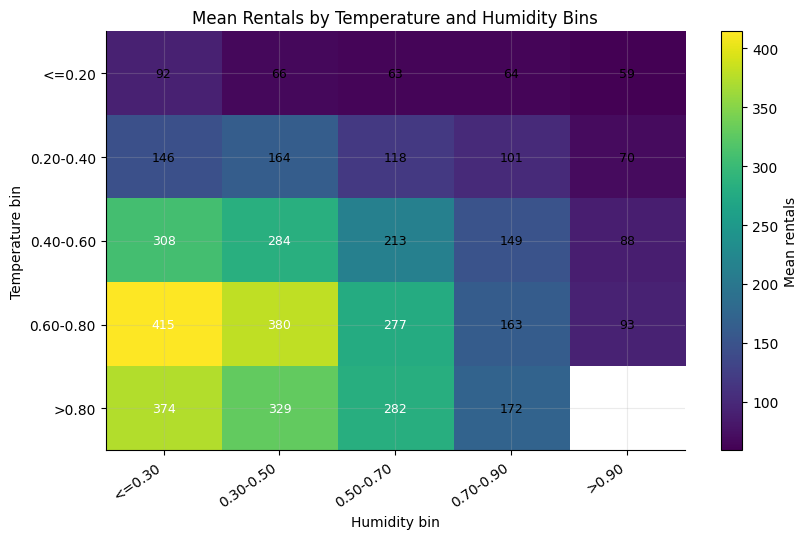

In [18]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
im = ax.imshow(temp_hum_pivot.values.astype(float), aspect="auto", cmap="viridis")

ax.set_title("Mean Rentals by Temperature and Humidity Bins")
ax.set_xlabel("Humidity bin")
ax.set_ylabel("Temperature bin")
ax.set_xticks(range(temp_hum_pivot.shape[1]))
ax.set_xticklabels(temp_hum_pivot.columns, rotation=35, ha="right")
ax.set_yticks(range(temp_hum_pivot.shape[0]))
ax.set_yticklabels(temp_hum_pivot.index)

for i in range(temp_hum_pivot.shape[0]):
    for j in range(temp_hum_pivot.shape[1]):
        value = temp_hum_pivot.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.0f}", ha="center", va="center", color="white" if value > 250 else "black", fontsize=9)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Mean rentals")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "temp_humidity_heatmap.png", dpi=200)
plt.show()


## 9. Casual vs Registered Riders

This comparison is useful for interpretation, but these columns should not be used as predictors of total demand because they add up to `cnt`.


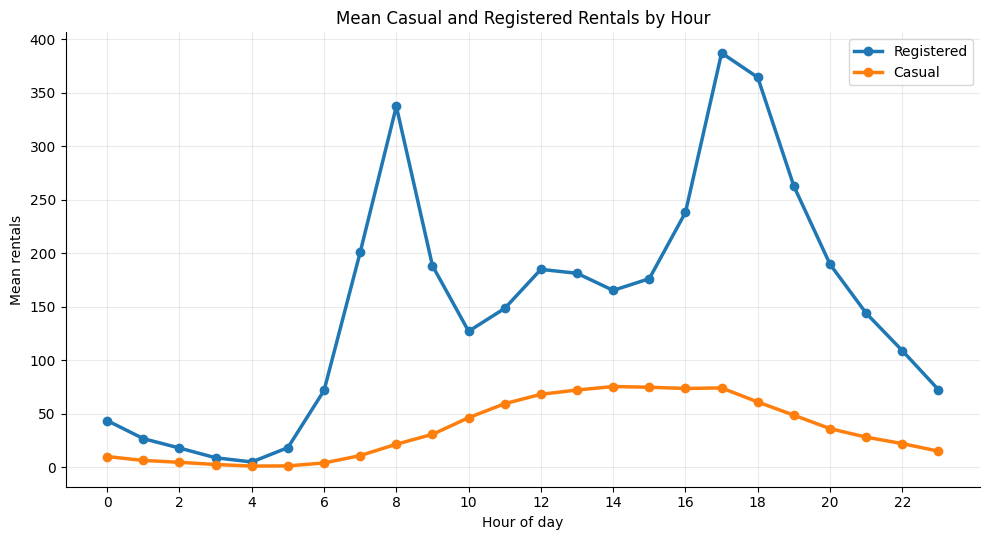

,casual,registered
hr,,
0,10.2,43.7
1,6.5,26.9
2,4.8,18.1
3,2.7,9.0
4,1.3,5.1


In [19]:
hour_components = df.groupby("hr")[["casual", "registered"]].mean()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(hour_components.index, hour_components["registered"], marker="o", linewidth=2.5, label="Registered")
ax.plot(hour_components.index, hour_components["casual"], marker="o", linewidth=2.5, label="Casual")

ax.set_title("Mean Casual and Registered Rentals by Hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean rentals")
ax.set_xticks(range(0, 24, 2))
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mean_casual_registered_by_hour.png", dpi=200)
plt.show()

hour_components.round(1).head()


## 10. Correlation Scan

This is not a final model because several variables are categorical or cyclical. It is still useful as a first-pass signal check. We exclude `casual` and `registered` from the displayed predictor list because they leak the target.


In [20]:
corr_cols = [
    "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit",
    "temp", "atemp", "hum", "windspeed", "cnt", "high_demand_flag"
]

corr = df[corr_cols].corr(numeric_only=True)
corr_with_cnt = corr["cnt"].drop("cnt").sort_values(ascending=False).round(3)
corr_with_cnt.to_frame("corr_with_cnt")


,corr_with_cnt
high_demand_flag,0.759
temp,0.405
atemp,0.401
hr,0.394
yr,0.250
mnth,0.121
windspeed,0.093
workingday,0.030
weekday,0.027
holiday,-0.031


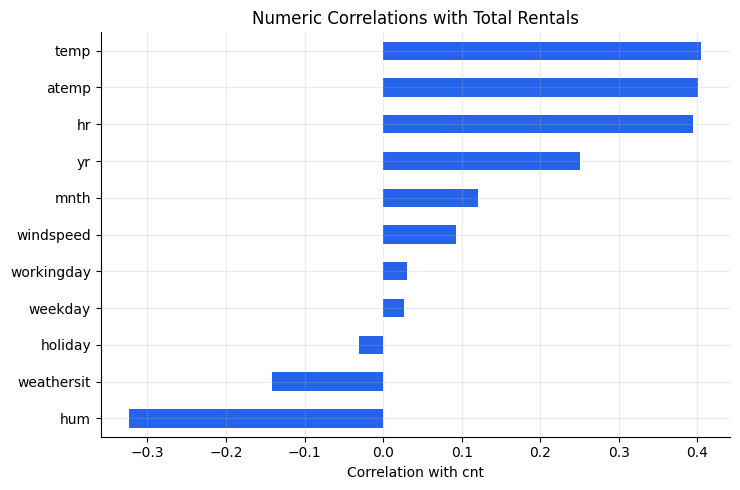

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 5))
corr_with_cnt.drop("high_demand_flag").sort_values().plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("Numeric Correlations with Total Rentals")
ax.set_xlabel("Correlation with cnt")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "correlation_with_cnt.png", dpi=200)
plt.show()


## 11. PCA Diagnostic on Cleaned Predictors


In [22]:
# Predictors that can be known before rental demand is observed--exclude casual, registered, cnt, and high_demand.
base_predictors = df[[
    "yr", "season", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit",
    "temp", "atemp", "hum", "windspeed",
]].copy()

categorical_cols = ["yr", "season", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit"]
X = pd.get_dummies(base_predictors, columns=categorical_cols, drop_first=False, dtype=float)

# Standardize as recommended for PCA and distance-based methods.
X_std = (X - X.mean()) / X.std(ddof=0).replace(0, np.nan)
X_std = X_std.fillna(0.0)

U, s, Vt = np.linalg.svd(X_std.to_numpy(), full_matrices=False)
explained_variance_ratio = (s ** 2) / np.sum(s ** 2)
scores = U * s

pca_rows = []
for k in range(5):
    loadings = pd.Series(Vt[k], index=X.columns)
    top_terms = loadings.abs().sort_values(ascending=False).head(8).index
    pca_rows.append({
        "PC": k + 1,
        "explained_variance_ratio": explained_variance_ratio[k],
        "corr_with_cnt": np.corrcoef(scores[:, k], df["cnt"])[0, 1],
        "top_loading_terms": "; ".join(f"{term} ({loadings[term]:+.2f})" for term in top_terms),
    })

pca_diagnostic = pd.DataFrame(pca_rows)
pca_diagnostic.round(3)


,PC,explained_variance_ratio,corr_with_cnt,top_loading_terms
0,1,0.066,0.359,temp (+0.47); atemp (+0.46); season_3 (+0.37);...
1,2,0.052,-0.056,workingday_1 (+0.54); workingday_0 (-0.54); we...
2,3,0.041,-0.115,season_4 (+0.47); hum (+0.36); season_1 (-0.30...
3,4,0.038,0.044,season_2 (-0.58); mnth_5 (-0.36); mnth_4 (-0.3...
4,5,0.035,0.100,holiday_0 (-0.58); holiday_1 (+0.58); weekday_...


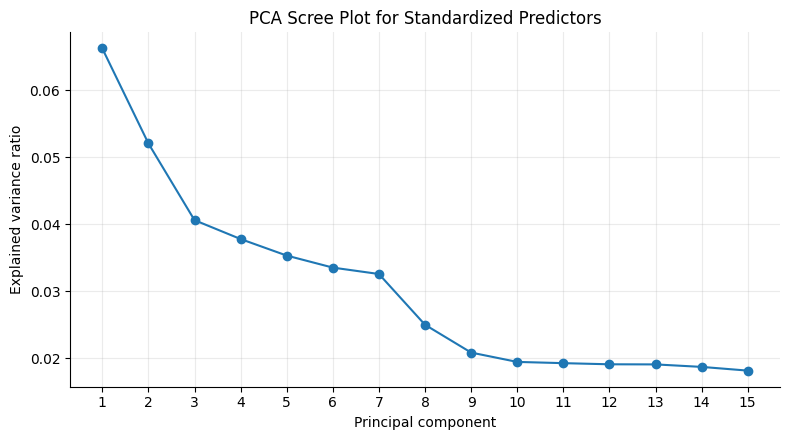

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, 16), explained_variance_ratio[:15], marker="o")
ax.set_title("PCA Scree Plot for Standardized Predictors")
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_xticks(np.arange(1, 16))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "predictor_pca_scree.png", dpi=200)
plt.show()
